--- Dataset Structure Preview ---
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


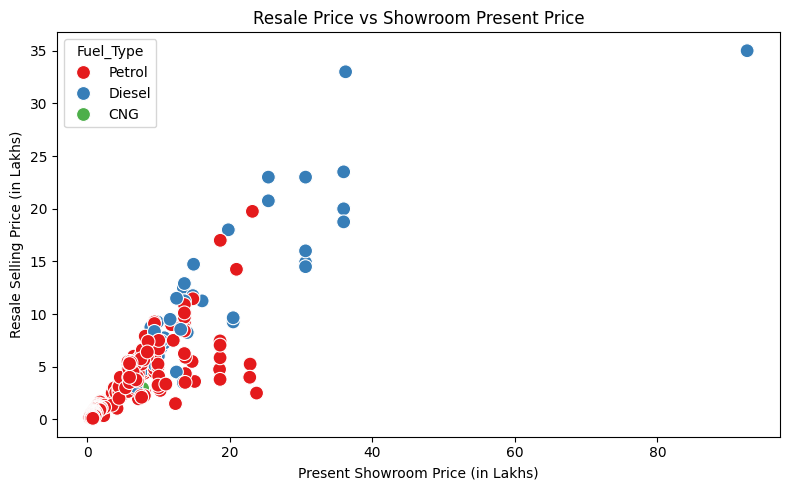


--- Model Evaluation Performance Results ---
Mean Absolute Error (MAE): 0.61 Lakhs
Model Accuracy (R-squared Score): 96.41%


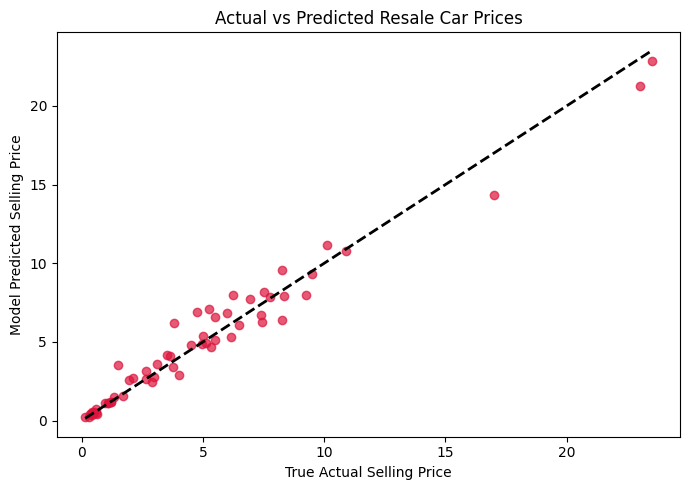

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
# Ensures your plots render automatically inside your notebook cells on Linux
%matplotlib inline
# 1. Load your uploaded dataset
# Make sure 'car data.csv' is saved in the exact same folder as this notebook file!
df = pd.read_csv('/home/wlug/Downloads/archive(1)/car data.csv')
print("--- Dataset Structure Preview ---")
print(df.head())
# 2. Exploratory Data Analysis (EDA)
# Visualizing how the showroom price (Present_Price) affects the resale value (Selling_Price)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type', palette='Set1', s=100)
plt.title('Resale Price vs Showroom Present Price')
plt.xlabel('Present Showroom Price (in Lakhs)')
plt.ylabel('Resale Selling Price (in Lakhs)')
plt.tight_layout()
plt.show()
# 3. Splitting Target and Data Features
# Target variable 'y' is what the model wants to predict
y = df['Selling_Price']
# Features 'X' includes all columns except the price and the unique car name text 
X = df.drop(columns=['Selling_Price', 'Car_Name'])
# Automatically separate categorical text labels and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
# 4. Creating Preprocessing & Training Pipeline
# Scale numeric columns to normalize distributions and encode text features into math matrices
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
# Chain the steps together into a unified ML Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
# 5. Training the Machine Learning Model
# Split data into 80% training and 20% validation test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train the Random Forest
model_pipeline.fit(X_train, y_train)
# 6. Evaluation Metrics 
y_pred = model_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\n--- Model Evaluation Performance Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} Lakhs")
print(f"Model Accuracy (R-squared Score): {r2 * 100:.2f}%")
# Plotting Actual Price vs Predictions
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='crimson', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('True Actual Selling Price')
plt.ylabel('Model Predicted Selling Price')
plt.title('Actual vs Predicted Resale Car Prices')
plt.tight_layout()
plt.show()